# Testing user-supplied transit times with TOI-216 b and c

This notebook exercises the explicit, multi-planet transit-time masking path using TESS PDCSAP data for the strongly interacting TOI-216 system. Both planets exhibit large, anticorrelated transit-timing variations (TTVs).

The individual TESS mid-transit times below come from Table 3 of [Dawson et al. (2019)](https://doi.org/10.3847/1538-3881/ab24ba). The paper reports times near 1300–1500 days; these are converted from the TESS convention (BJD − 2457000) to full BJD because `input_transit_times` expects full BJD. Ground-based timings listed in the same table are deliberately excluded. A later analysis confirms that TOI-216 b and c have exceptionally large TTVs ([McKee & Montet 2023](https://doi.org/10.3847/1538-3881/accd66)).

The notebook first tests the masks directly, then runs the PDC-only detrending path with problem-time labeling disabled. Downloads require internet access and the full detrending cell can take a while.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make the local source tree importable even when this notebook kernel does
# not have democratic_detrender installed as a package. This works when the
# notebook server starts in the repository, a parent, or a subdirectory.
search_roots = [Path.cwd(), *Path.cwd().parents]
for search_root in search_roots:
    possible_roots = [search_root, search_root / "democratic_detrender"]
    for project_root in possible_roots:
        if (project_root / "democratic_detrender" / "get_lc.py").is_file():
            sys.path.insert(0, str(project_root))
            break
    else:
        continue
    break
else:
    raise FileNotFoundError(
        "Could not locate the democratic_detrender source tree. "
        "Start Jupyter within the cloned repository or install it with `pip install -e .`."
    )

print(f"Importing democratic_detrender from: {project_root}")

from democratic_detrender.get_lc import get_light_curve, get_transit_info
from democratic_detrender.detrend import detrend_all
from democratic_detrender.democratic_detrend import democratic_detrend

Importing democratic_detrender from: /Users/daniel/Desktop/dd_github/democratic_detrender


/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/daniel/.lightkurve/cache. Please move all the files in the legacy directory /Users/daniel/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(
/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/pymc_ext/optim.py:4: FutureWarning: `pytensor.graph.basic.graph_inputs` was moved to `pytensor.graph.traversal.graph_inputs`. Calling it from the old location wil

## Published TESS transit centers

These are measured centers rather than times generated from a constant-period ephemeris. Planet b has a missing epoch between 1393.723 and 1427.879; the explicit-time masking code must not invent a transit in that gap.

In [2]:
BJD_OFFSET = 2457000.0

# Dawson et al. (2019), Table 3: TESS timings only.
toi216_b_btjd = np.array([
    1325.328, 1342.431, 1359.539, 1376.631, 1393.723,
    1427.879, 1444.958, 1462.031, 1479.094, 1496.155, 1513.225,
])
toi216_c_btjd = np.array([
    1331.2851, 1365.8245, 1400.3686, 1434.9227, 1469.4773,
])

toi216_b_bjd = toi216_b_btjd + BJD_OFFSET
toi216_c_bjd = toi216_c_btjd + BJD_OFFSET

print(f"Loaded {len(toi216_b_bjd)} timings for b and {len(toi216_c_bjd)} for c.")

Loaded 11 timings for b and 5 for c.


## Match planet names to the archive row ordering

The package's `planet_number` is the one-based row number printed by `get_light_curve`, not necessarily alphabetical planet order. We therefore identify b and c by their approximately 17.1-day and 34.55-day periods instead of assuming which archive row comes first.

In [3]:
TARGET = "TOI-216"
transit_info = get_transit_info(TARGET).reset_index(drop=True)
display(transit_info[["tic_id", "t0 [BJD]", "period [days]", "duration [hours]"]])

archive_periods = transit_info["period [days]"].to_numpy(dtype=float)
planet_number_b = int(np.argmin(np.abs(archive_periods - 17.1))) + 1
planet_number_c = int(np.argmin(np.abs(archive_periods - 34.55))) + 1
assert planet_number_b != planet_number_c

transit_times_by_planet = {
    planet_number_b: toi216_b_bjd,
    planet_number_c: toi216_c_bjd,
}
print(f"Package planet number for TOI-216 b: {planet_number_b}")
print(f"Package planet number for TOI-216 c: {planet_number_c}")

Exoplanet Archive: Planet Comparison Table
------------------------------------------


,tic_id,t0 [BJD],period [days],duration [hours]
0,TIC 55652896,2.458331e+06,34.525528,3.820665
1,TIC 55652896,2.458325e+06,17.160730,2.062000


Package planet number for TOI-216 b: 2
Package planet number for TOI-216 c: 1


In [10]:
transit_times_by_planet

{2: array([2458325.328, 2458342.431, 2458359.539, 2458376.631, 2458393.723,
        2458427.879, 2458444.958, 2458462.031, 2458479.094, 2458496.155,
        2458513.225]),
 1: array([2458331.2851, 2458365.8245, 2458400.3686, 2458434.9227,
        2458469.4773])}

## Direct mask test

This downloads TESS PDCSAP light curves and asks `get_light_curve` to use the measured times for both planets. We fit planet b, so `mask` should contain b and c while `mask_fitted_planet` should contain only b.

In [4]:
(
    time, flux, flux_err, mask, mask_fitted_planet, t0s_in_data,
    period, duration, quarters, crowding, flux_fraction,
) = get_light_curve(
    TARGET,
    "pdcsap_flux",
    TESS=True,
    planet_number=planet_number_b,
    mask_width=1.1,
    user_transit_times=transit_times_by_planet,
)

# get_light_curve returns TESS-relative times after accepting full BJD input.
expected_b_in_data = toi216_b_btjd[(toi216_b_btjd >= time.min()) & (toi216_b_btjd <= time.max())]
assert np.allclose(t0s_in_data, expected_b_in_data)

# Every measured center with nearby TESS data should land inside the appropriate mask.
for center in expected_b_in_data:
    nearest = np.argmin(np.abs(time - center))
    assert mask_fitted_planet[nearest]
    assert mask[nearest]

expected_c_in_data = toi216_c_btjd[(toi216_c_btjd >= time.min()) & (toi216_c_btjd <= time.max())]
for center in expected_c_in_data:
    nearest = np.argmin(np.abs(time - center))
    assert mask[nearest]

# The missing b epoch is intentionally not supplied and should not be masked as b.
missing_b_epoch = 1410.8
missing_nearest = np.argmin(np.abs(time - missing_b_epoch))
assert not mask_fitted_planet[missing_nearest]

print("Direct explicit-time mask checks passed.")

Exoplanet Archive: Planet Comparison Table
------------------------------------------
NASA Exoplanet Archive planet parameters:
planet #, [    tic_id      ,    t0 [BJD]    ,  P [days]   , tdur [hrs]]
planet 1, ['TIC 55652896', '2458331.411', '34.525528', '3.8206653']
planet 2, ['TIC 55652896', '2458324.5911', '17.16073', '2.062']




/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/lightkurve/search.py:491: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


using the following params for the planet we are fitting
--------------------------------------------------------
[  t0 [TESS BJD]  , P [days], tdur [hrs]
[1325.3280000002123, 17.16073, [2.062]]

10 transits (or epochs) in total

Direct explicit-time mask checks passed.


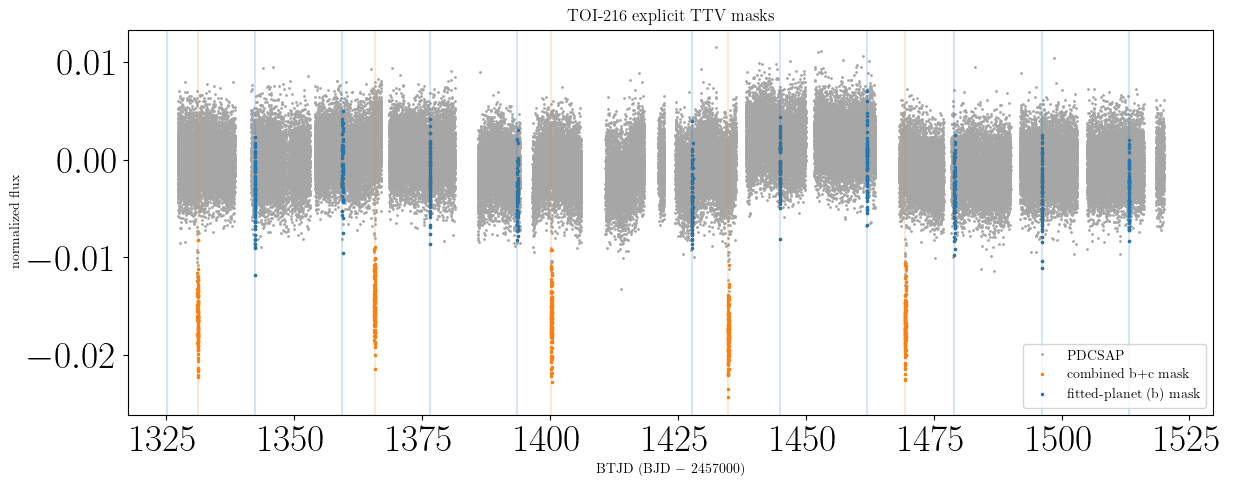

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
year_1 = (time > 1315) & (time < 1520)
ax.plot(time[year_1], flux[year_1], ".", color="0.65", ms=2, label="PDCSAP")
ax.plot(time[year_1 & mask], flux[year_1 & mask], ".", color="tab:orange", ms=3, label="combined b+c mask")
ax.plot(time[year_1 & mask_fitted_planet], flux[year_1 & mask_fitted_planet], ".", color="tab:blue", ms=3, label="fitted-planet (b) mask")
for center in toi216_b_btjd:
    ax.axvline(center, color="tab:blue", alpha=0.18)
for center in toi216_c_btjd:
    ax.axvline(center, color="tab:orange", alpha=0.18)
ax.set(xlabel="BTJD (BJD − 2457000)", ylabel="normalized flux", title="TOI-216 explicit TTV masks")
ax.legend();

## PDC-only detrending test

`flux_type="pdc"` selects only PDCSAP data. `input_no_pdc_problem_times=True` takes the non-interactive path that assumes there are no PDC problem times, so no manual labeling window is opened. `input_reject_outliers=False` skips both outlier-rejection passes for this speed-focused mask test. The custom output directory prevents an older cached run from being mistaken for this test.

Exoplanet Archive: Planet Comparison Table
------------------------------------------
NASA Exoplanet Archive planet parameters:
planet #, [    tic_id      ,    t0 [BJD]    ,  P [days]   , tdur [hrs]]
planet 1, ['TIC 55652896', '2458331.411', '34.525528', '3.8206653']
planet 2, ['TIC 55652896', '2458324.5911', '17.16073', '2.062']




/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/lightkurve/search.py:491: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


using the following params for the planet we are fitting
--------------------------------------------------------
[  t0 [TESS BJD]  , P [days], tdur [hrs]
[1325.3280000002123, 17.16073, [2.062]]

10 transits (or epochs) in total

skipping outlier rejection
assuming no pdc problem times


detrending now
--------------


detrending via the local method
local detrending completed in 0.3 seconds

detrending via the polyAM method


/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


polyAM detrending completed in 0.98 seconds

detrending via the GP method


...

Output()

GP detrending completed in 6.02 seconds

detrending via the CoFiAM method


/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


CoFiAM completed in 49.63 seconds
PDC-only detrending completed; outputs are in /Users/daniel/Desktop/dd_github/democratic_detrender/docs/tutorials/toi216_ttv_pdc_test


,time,yerr,mask,method marginalized,local PDCSAP,polyAM PDCSAP,GP PDCSAP,CoFiAM PDCSAP
0,1341.915551,0.002679,False,-0.001004,-0.000746,-0.001004,NaN,-0.001092
1,1341.91694,0.002679,False,0.000048,0.000302,0.000048,NaN,-0.000040
2,1341.918329,0.002679,False,0.005103,0.005355,0.005103,NaN,0.005016
3,1341.919718,0.002676,False,0.001159,0.001405,0.001159,NaN,0.001072
4,1341.921107,0.002676,False,0.001462,0.001704,0.001462,NaN,0.001376


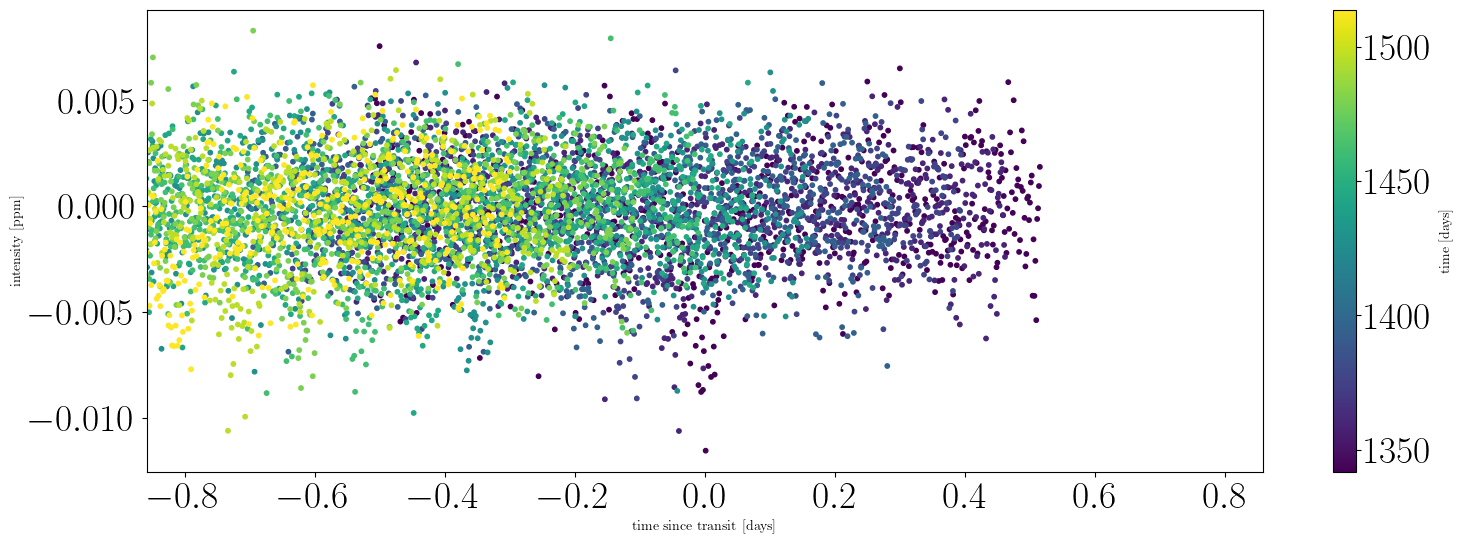

In [6]:
output_dir = Path("toi216_ttv_pdc_test").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

detrended, fitted_t0s, fitted_period, fitted_duration = detrend_all(
    TARGET,
    "TESS",
    flux_type="pdc",
    input_planet_number=planet_number_b,
    input_dir=str(output_dir),
    input_transit_times=transit_times_by_planet,
    input_reject_outliers=False,
    input_no_pdc_problem_times=True,
    input_show_plots=False,
)

assert np.allclose(fitted_t0s, expected_b_in_data)
assert (output_dir / "detrended.csv").exists()
assert (output_dir / "t0s.csv").exists()
print(f"PDC-only detrending completed; outputs are in {output_dir}")
detrended.head()

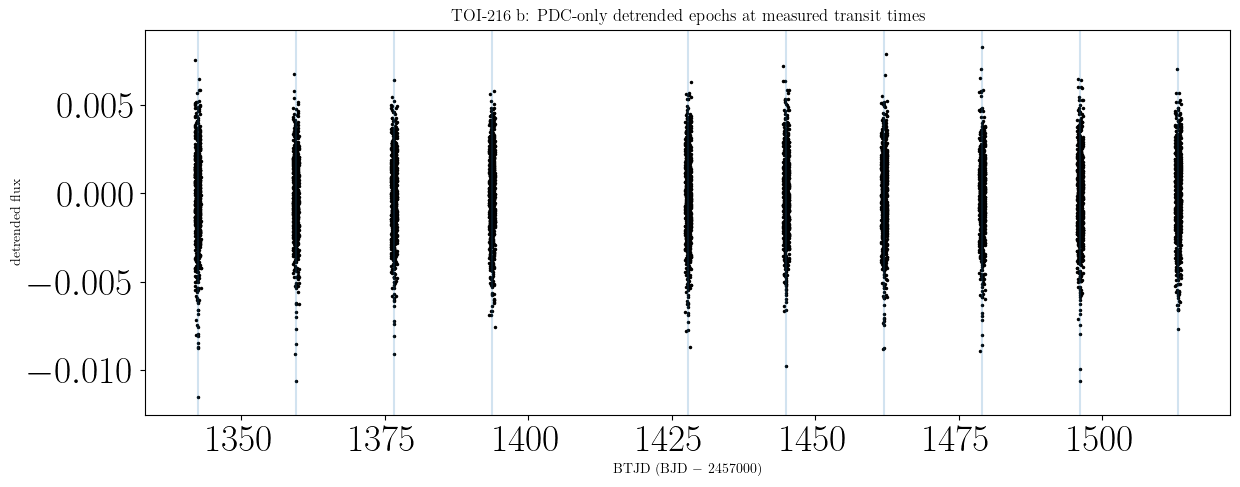

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(detrended["time"], detrended["method marginalized"], ".", ms=3, color="black")
for center in fitted_t0s:
    ax.axvline(center, color="tab:blue", alpha=0.2)
ax.set(xlabel="BTJD (BJD − 2457000)", ylabel="detrended flux", title="TOI-216 b: PDC-only detrended epochs at measured transit times");

## TTV-corrected phase-folded transit

A conventional fold on a single linear ephemeris would smear TOI-216 b because its transits do not occur at strictly periodic times. Instead, the cell below centers each cadence on the nearest user-supplied `t0`, then expresses that offset as orbital phase. This preserves the transit shape while accounting for the measured TTVs.

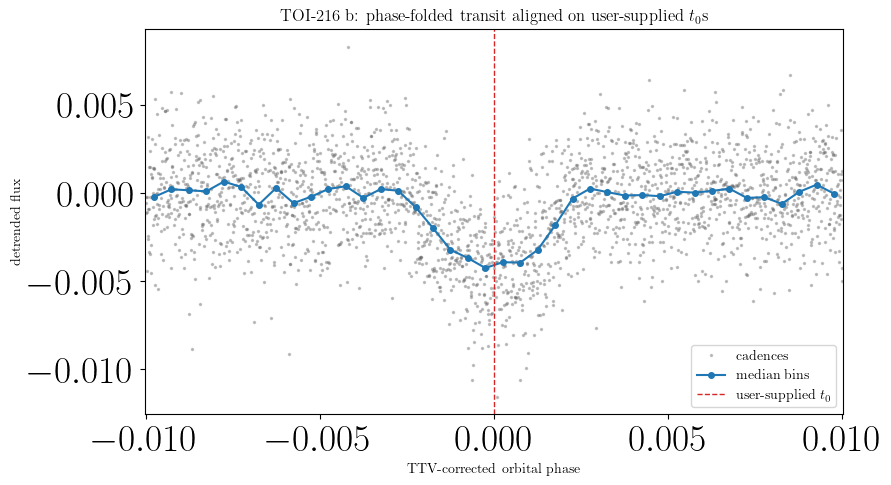

In [8]:
# Use the supplied centers directly (converted from BJD to the BTJD time basis
# used by the detrended light curve).
user_t0s_btjd = np.asarray(transit_times_by_planet[planet_number_b]) - BJD_OFFSET
user_t0s_btjd = user_t0s_btjd[(user_t0s_btjd >= detrended["time"].min()) &
                                  (user_t0s_btjd <= detrended["time"].max())]

fold_time = detrended["time"].to_numpy(dtype=float)
fold_flux = detrended["method marginalized"].to_numpy(dtype=float)
nearest_t0 = user_t0s_btjd[np.argmin(
    np.abs(fold_time[:, None] - user_t0s_btjd[None, :]), axis=1
)]
fold_period = float(np.asarray(fitted_period).squeeze())
ttv_phase = (fold_time - nearest_t0) / fold_period

# Show two transit durations on either side of the measured center.
phase_limit = 2.0 * float(np.asarray(fitted_duration).squeeze()) / (24.0 * fold_period)
in_window = np.isfinite(fold_flux) & (np.abs(ttv_phase) <= phase_limit)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ttv_phase[in_window], fold_flux[in_window], ".", ms=3, alpha=0.3, color="0.35", label="cadences")

# Overlay median bins to make the combined transit shape easier to see.
bin_edges = np.linspace(-phase_limit, phase_limit, 41)
bin_index = np.digitize(ttv_phase[in_window], bin_edges)
bin_phase = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_flux = np.array([
    np.nanmedian(fold_flux[in_window][bin_index == i])
    if np.any(bin_index == i) else np.nan
    for i in range(1, len(bin_edges))
])
ax.plot(bin_phase, bin_flux, "o-", ms=4, lw=1.5, color="tab:blue", label="median bins")
ax.axvline(0, color="tab:red", ls="--", lw=1, label="user-supplied $t_0$")
ax.set(
    xlim=(-phase_limit, phase_limit),
    xlabel="TTV-corrected orbital phase",
    ylabel="detrended flux",
    title="TOI-216 b: phase-folded transit aligned on user-supplied $t_0$s",
)
ax.legend();

## Full democratic detrending and method rejection for both planets

Ok everything looks good, so lets `democratic_detrend` to run the complete pipeline: PDCSAP detrending, all four enabled detrending families, and the final white-noise-based method-rejection stage. Because the API fits one planet at a time, we run it once for b and once for c. In both runs, `input_transit_times` contains the user-supplied centers for **both** planets; the selected planet is fitted while the other planet is still masked.

This is substantially slower than the detrend only demonstration above. Method rejection performs Monte Carlo tests for every epoch and writes its diagnostic figures and post-rejection CSV into each planet's output directory.

Running the full democratic detrending pipeline for TOI-216 b...
Exoplanet Archive: Planet Comparison Table
------------------------------------------
NASA Exoplanet Archive planet parameters:
planet #, [    tic_id      ,    t0 [BJD]    ,  P [days]   , tdur [hrs]]
planet 1, ['TIC 55652896', '2458331.411', '34.525528', '3.8206653']
planet 2, ['TIC 55652896', '2458324.5911', '17.16073', '2.062']




/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/lightkurve/search.py:491: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


using the following params for the planet we are fitting
--------------------------------------------------------
[  t0 [TESS BJD]  , P [days], tdur [hrs]
[1325.3280000002123, 17.16073, [2.062]]

10 transits (or epochs) in total

skipping outlier rejection
assuming no pdc problem times


detrending now
--------------


detrending via the local method
local detrending completed in 0.3 seconds

detrending via the polyAM method


/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


polyAM detrending completed in 1.0 seconds

detrending via the GP method


...

/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/pytensor/tensor/random/op.py:97: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/Users/daniel/Desktop/dd_github/.venv/lib/python3.12/site-packages/pytensor/tensor/random/op.py:107: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(


Output()

GP detrending completed in 4.71 seconds

detrending via the CoFiAM method
CoFiAM completed in 37.32 seconds
detrending methods used: ['local PDCSAP', 'polyAM PDCSAP', 'GP PDCSAP', 'CoFiAM PDCSAP']

starting individual model rejection via DW metric:
--------------------------------------------------
DW rejection completed in : 4.251097917556763 seconds


starting individual model rejection via binning vs. RMS test:
--------------------------------------------------
Execution time: 139.14054894447327 seconds
Finished TOI-216 c; results saved to /Users/daniel/Desktop/dd_github/democratic_detrender/docs/tutorials/toi216_full_democratic_detrend/TOI-216_c


,time,yerr,mask,method marginalized,local PDCSAP,polyAM PDCSAP,GP PDCSAP,CoFiAM PDCSAP
0,1341.915551,0.002682,False,-0.001004,-0.000746,-0.001004,NaN,-0.001092
1,1341.916940,0.002682,False,0.000048,0.000302,0.000048,NaN,-0.000040
2,1341.918329,0.002682,False,0.005103,0.005355,0.005103,NaN,0.005016
3,1341.919718,0.002679,False,0.001159,0.001405,0.001159,NaN,0.001072
4,1341.921107,0.002679,False,0.001462,0.001704,0.001462,NaN,0.001376


,time,yerr,mask,method marginalized,local PDCSAP,polyAM PDCSAP,GP PDCSAP,CoFiAM PDCSAP
0,1330.330703,0.002468,False,-0.001358,-0.001432,-0.001348,-0.001366,-0.001350
1,1330.332092,0.002468,False,-0.003141,-0.003215,-0.003131,-0.003149,-0.003133
2,1330.333481,0.002467,False,-0.003425,-0.003499,-0.003415,-0.003433,-0.003417
3,1330.334870,0.002473,False,0.003827,0.003752,0.003837,0.003819,0.003836
4,1330.336259,0.002468,False,-0.001478,-0.001553,-0.001469,-0.001487,-0.001470


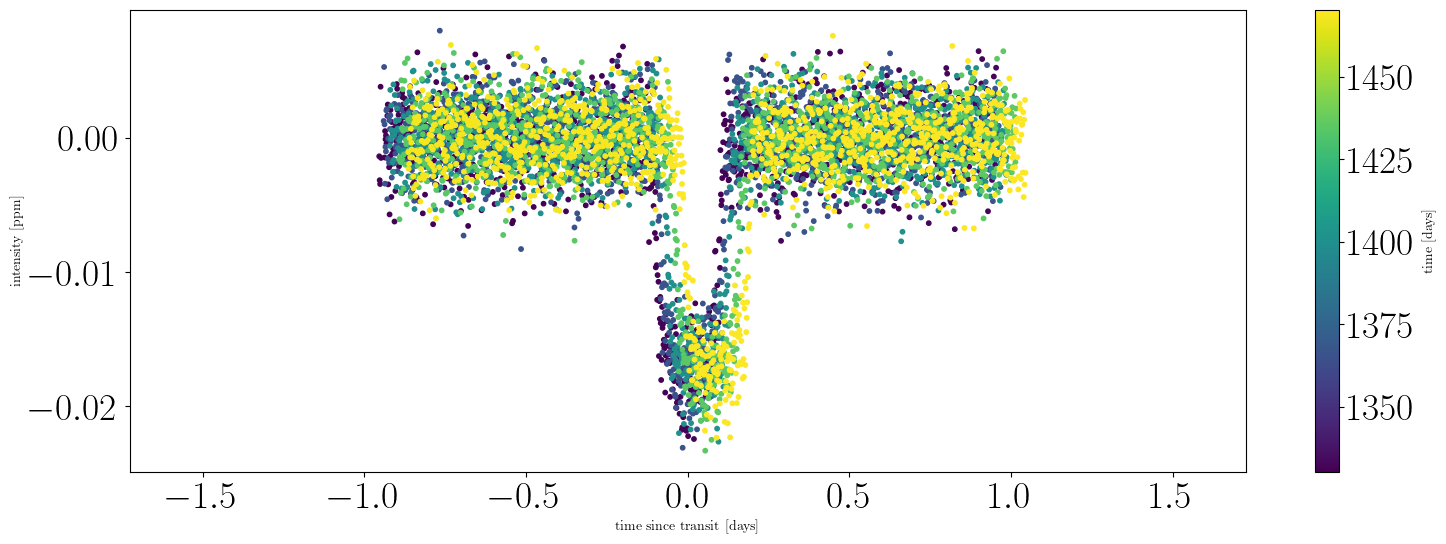

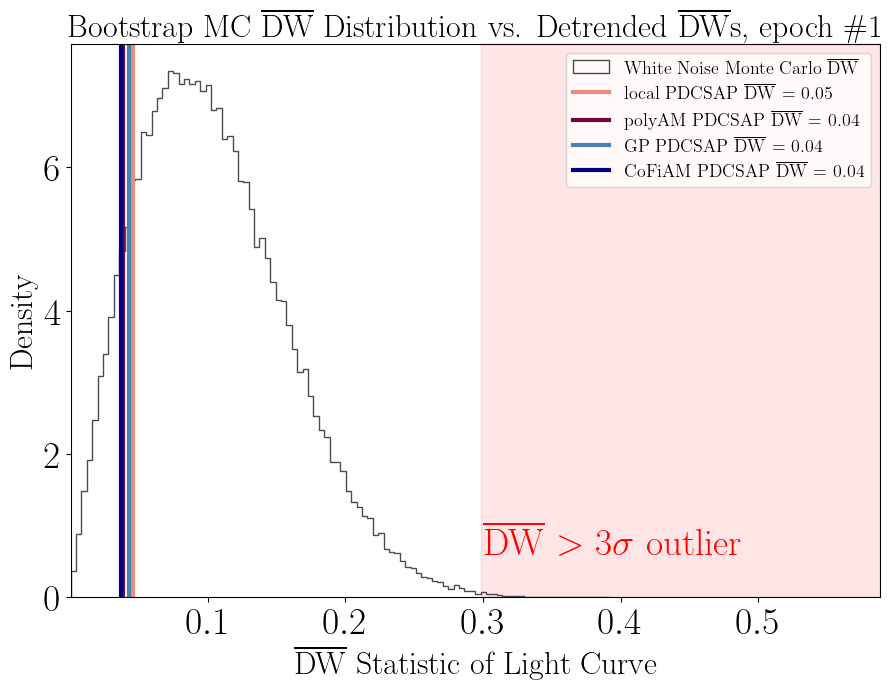

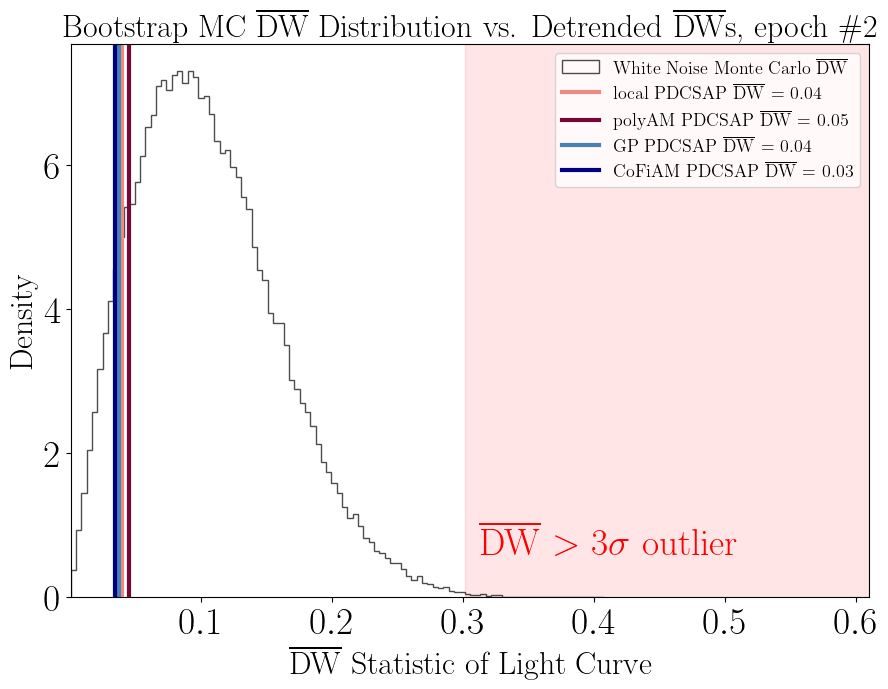

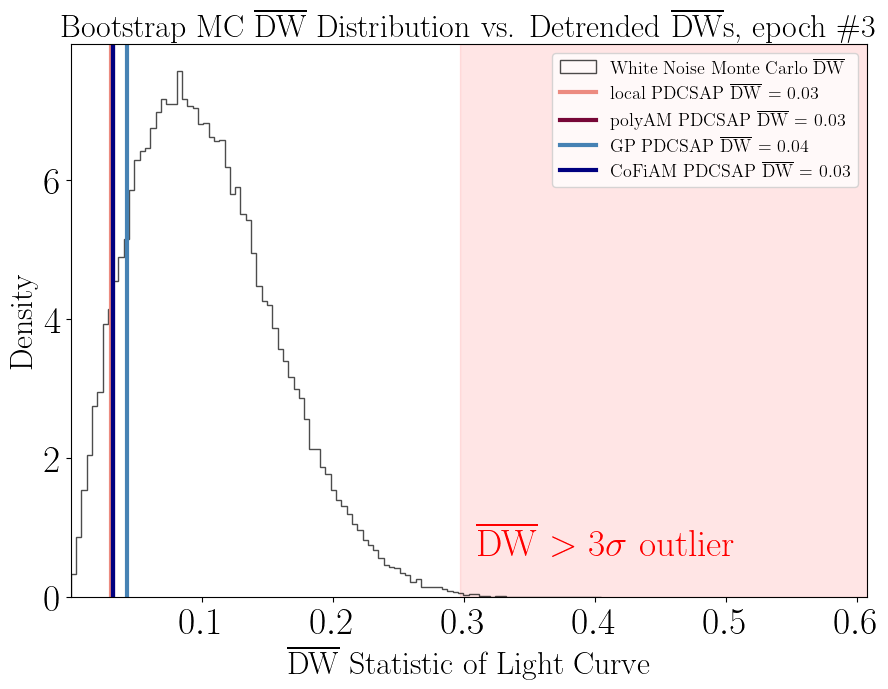

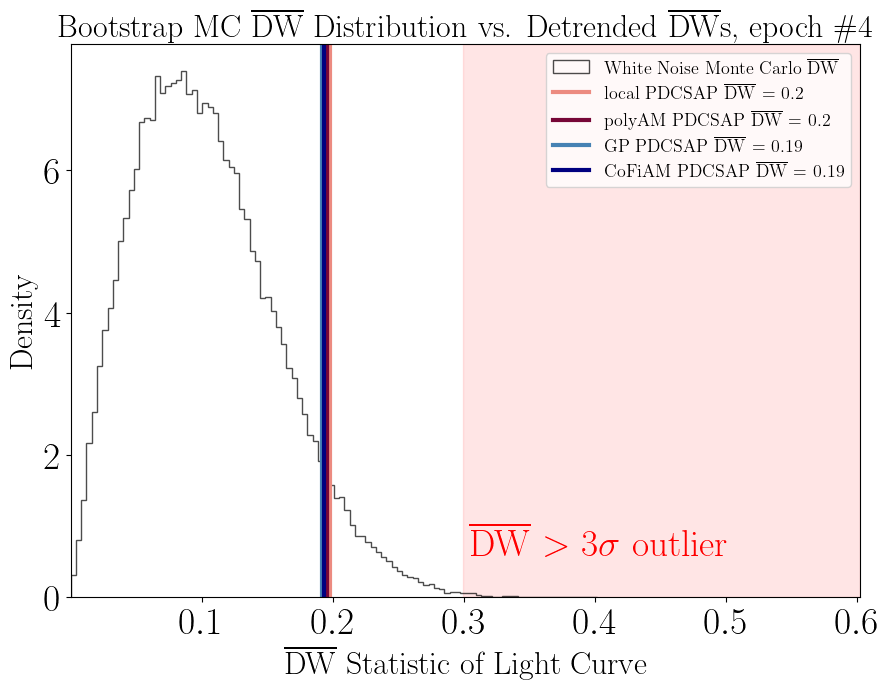

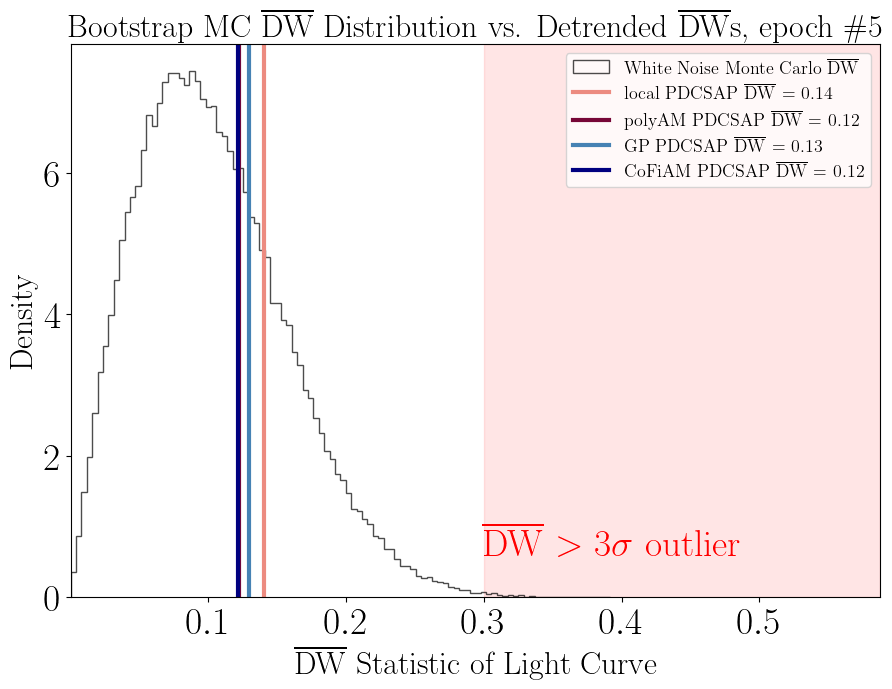

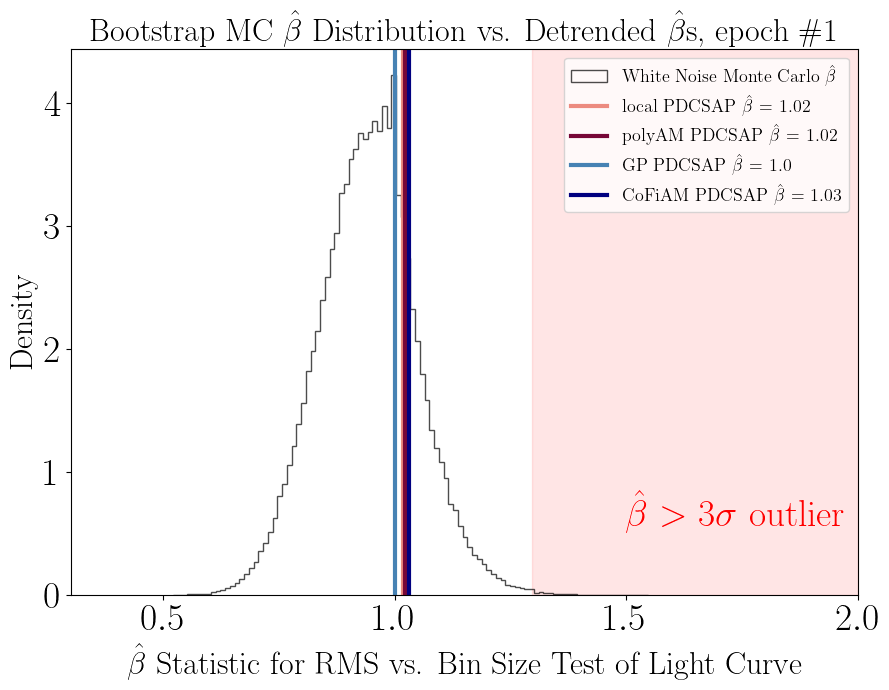

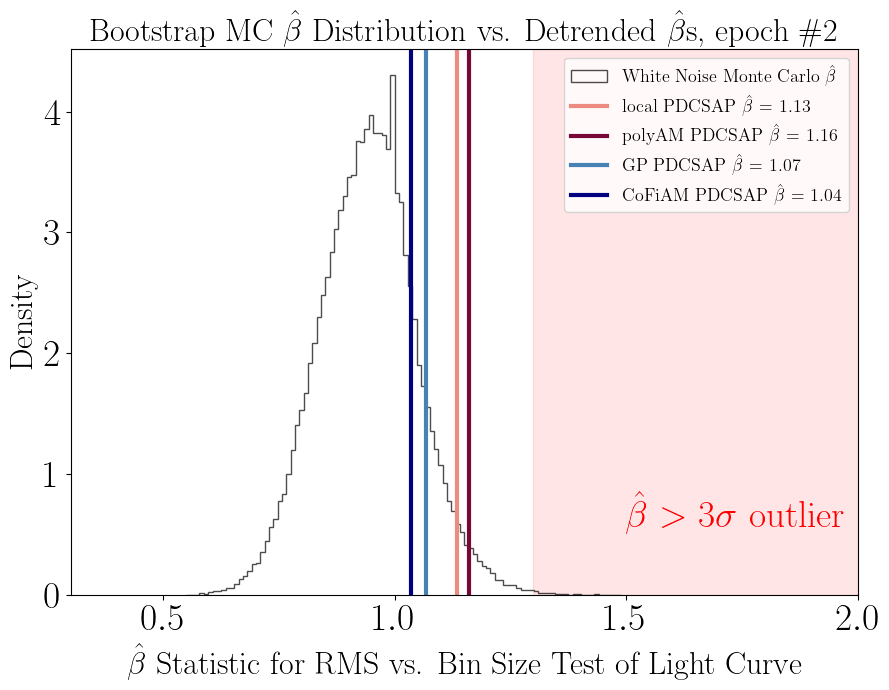

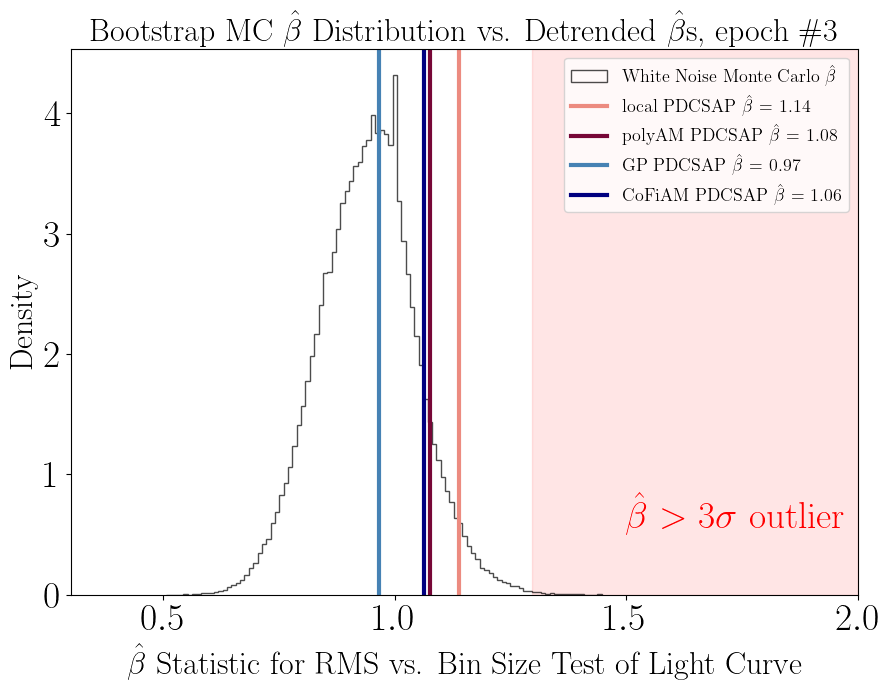

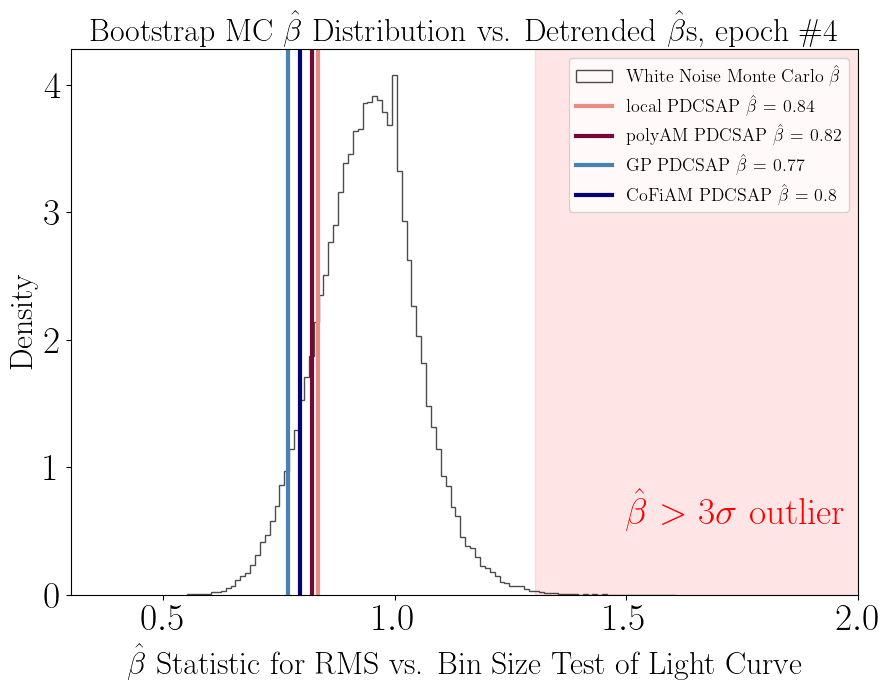

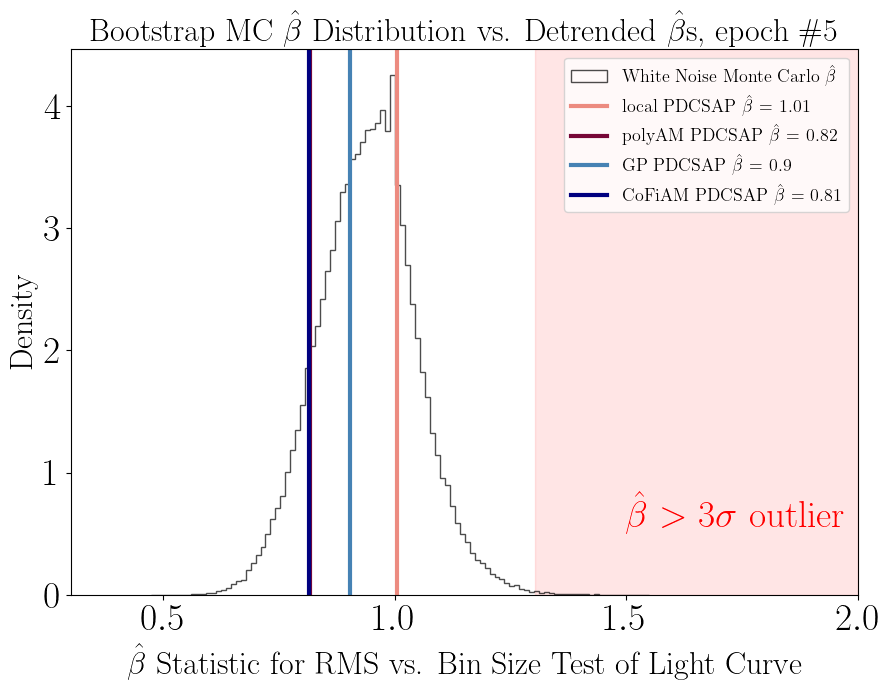

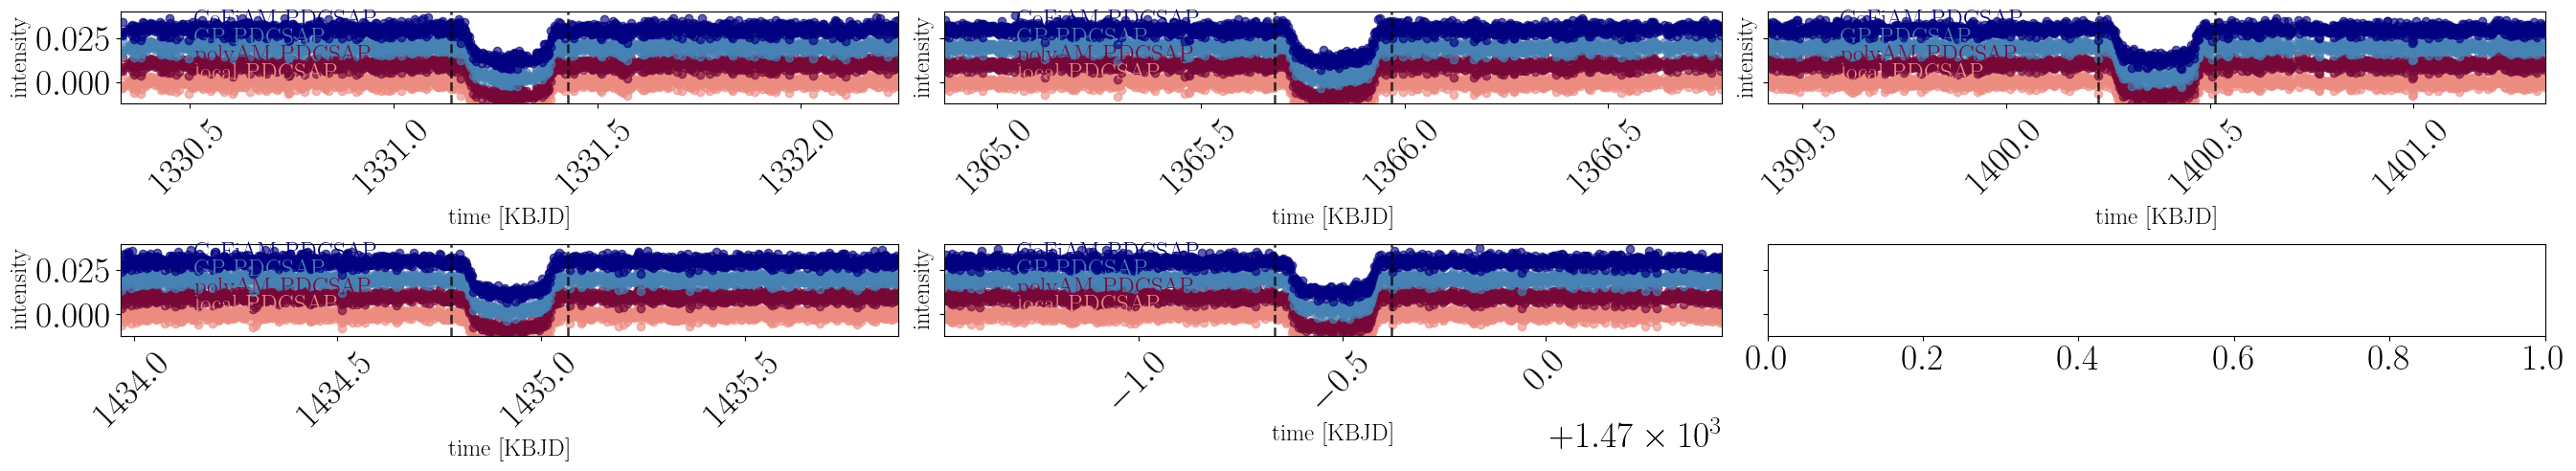

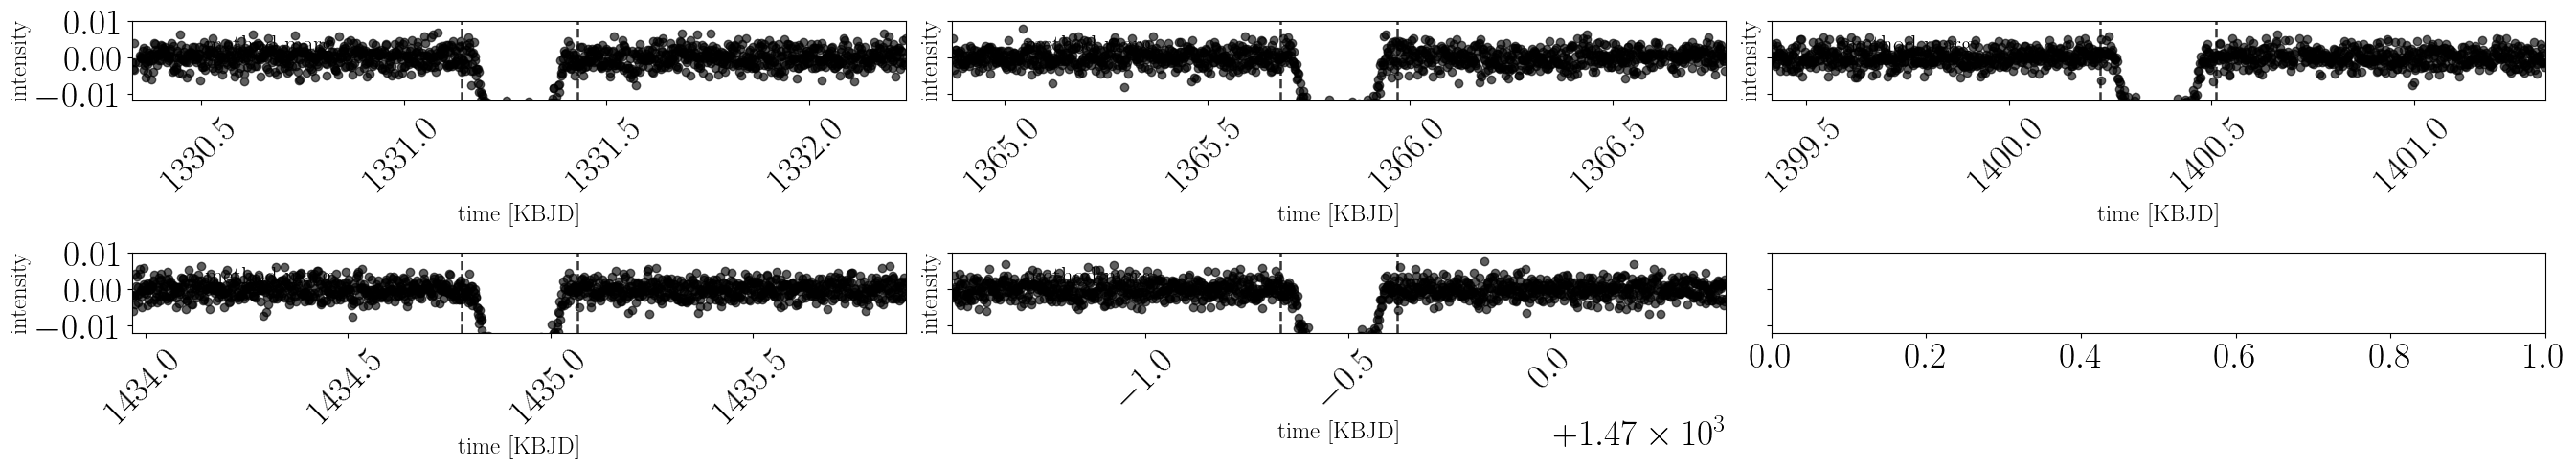

In [4]:
full_run_root = Path("toi216_full_democratic_detrend").resolve()
full_results = {}

for planet_name, planet_number in {
    "b": planet_number_b,
    "c": planet_number_c,
}.items():
    planet_output_dir = full_run_root / f"TOI-216_{planet_name}"
    planet_output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Running the full democratic detrending pipeline for TOI-216 {planet_name}...")

    #longer mask width bc it looks like duration is underestimated for planet c
    if planet_name == 'c':
        mw = 1.8
    else:
        mw = 1.1

    full_results[planet_name] = democratic_detrend(
        TARGET,
        "TESS",
        flux_type="pdc",
        input_planet_number=planet_number,
        input_dir=str(planet_output_dir),
        input_transit_times=transit_times_by_planet,
        input_no_pdc_problem_times=True,
        input_show_plots=False,
        input_reject_outliers=False,
        input_polyAM=True,
        input_CoFiAM=True,
        input_GP=True,
        input_local=True,
        input_mask_width=mw 
    )

    post_rejection_file = planet_output_dir / "detrended_post_method_rejection.csv"
    assert post_rejection_file.exists()
    print(f"Finished TOI-216 {planet_name}; results saved to {planet_output_dir}")

display(full_results["b"].head())
display(full_results["c"].head())